# Chapter 2: Exploring Tabular Datasets

## 1. Characteristics of Rows

#### Independent and Identically Distributed (IID)

When working with tabular data, it's important to ensure that each row (i.e., example) is **independent and identically distributed (IID)** — unless you're dealing with time series or hierarchical data. IID means that each sample is drawn independently from the same underlying distribution, like repeated coin flips or dice rolls. This assumption simplifies many aspects of machine learning, such as model training, cross-validation, and sampling methods like bootstrapping. 

However, many real-world datasets violate the IID assumption. For instance, sales from the same store or responses from students in the same class tend to be correlated, introducing non-IID characteristics. Non-IID data can lead to misleading model performance, overfitting to hidden relationships, and biased validation scores. It's important to detect these patterns through data exploration and understand how they might impact your modeling process.

#### Why IID Matters in Machine Learning

Most statistical and machine learning methods assume that data is **independent and identically distributed (IID)**. While machine learning is often data-driven and nonparametric, it still relies heavily on the IID assumption to make reliable predictions. In reality, most datasets are not truly IID.

A key limitation of machine learning algorithms is that they are **column-aware but not row-aware**—they learn relationships between features and the target but cannot understand dependencies between rows. This means that if data has hidden patterns due to time or grouping, the model may wrongly interpret them as feature-based correlations.

**Time series and longitudinal data** are classic examples of non-IID data, where observations are autocorrelated. In such cases, time-based features (e.g., timestamps or lagged variables) help the model account for temporal dependencies. Depending on your data structure, you can:

* Use timestamps as features (for proper time series analysis with special validation techniques).
* Create time-based features by pivoting multiple time points into separate columns, allowing the data to be treated as IID.

Properly identifying and handling non-IID structures is essential to avoid misleading results and to ensure your models generalize well.


#### Handling Non-IID Data in Time and Groups

Even in **cross-sectional datasets**, comparing different time periods can introduce **temporal dependencies**, making the data non-IID—even when there's no interaction between units or groups. In such cases, the **order of observations matters**, and time series models become necessary to capture the correlation across time points.

To prepare data effectively for modeling:

* **Check how time affects your data**, and consider using **time features**, **lags**, or **moving averages** to control for temporal shifts.
* Be **explicit about grouping**: if hidden relationships or groups exist in your data, represent them with features and use **group-aware validation techniques**.
* For grouped data, prefer **group cross-validation** to avoid splitting related rows across train and validation sets.
* For temporal data, use **time-based validation** methods to preserve the order and avoid data leakage.

Properly addressing these issues improves model reliability and prevents overfitting to spurious or time-based patterns.



## 2. Characteristics of Columns

#### A. Types

It is important to understand the types of data that can be dealth with. Each type requires a special type of processing and needs specific way of dealing with it.



| **Feature Type**      | **Description**                                                             | **Examples**                     | **Key Notes**                                                           |
| --------------------- | --------------------------------------------------------------------------- | -------------------------------- | ----------------------------------------------------------------------- |
| **Numeric (Float)**   | Real numbers; can be **ratio** (true zero) or **interval** (arbitrary zero) | Price, weight, temperature       | Can standardize; ensure consistent units; interval data can be negative |
| **Numeric (Integer)** | Whole numbers; may also be **ordinal** or **categorical**                   | Count, age                       | Check continuity & uniqueness; treat carefully if used as labels        |
| **Ordinal**           | Ordered categories with **uneven spacing**                                  | Ratings (e.g., 1–5 stars), ranks | Do not compute mean/std; preserve order but not magnitude               |
| **Categorical**       | Unordered labels (strings or integers)                                      | Color, country, product type     | Handle with encoding; manage cardinality (low vs. high)                 |
| **Binary**            | Special case of categorical with **two values**                             | Yes/No, 0/1, presence/absence    | Often used directly in models                                           |
| **Date/Time**         | Temporal data                                                               | Timestamps, dates                | Decompose into parts (day, month, year); can convert to Unix time       |

---


#### B. Example of pandas dataframe 

Pandas DataFrames are the standard structure in Python for managing tabular data with mixed types (numeric, categorical, dates, etc.). They offer flexible access by row or column labels, support data cleaning, transformation, and visualization, and are now fully supported throughout Scikit-learn pipelines, keeping outputs as DataFrames instead of converting to NumPy arrays. The book uses pandas extensively to explore and fix common tabular data issues.

In [1]:
#Listing 2.1 Creating a simple tabular dataset
import pandas as pd

data = {'gender': ['male', 'female', 'male', 'female'],
        'age': [25, 30, 27, 29],
        'education_level': ['Bachelor', 'Master', 'Bachelor', 'PhD'],
        'income': [50000, 60000, 55000, 70000]} 

index = [ 'Bob ', 'Alice', 'Charlie', 'Emily'] 

df = pd.DataFrame(data, index=index) 

In [2]:
df

,gender,age,education_level,income
Bob,male,25,Bachelor,50000
Alice,female,30,Master,60000
Charlie,male,27,Bachelor,55000
Emily,female,29,PhD,70000


In [3]:
# print specific row and column based on index and column name
df.loc['Alice','age']

30

In [4]:
# print row with index "Alex"
df.loc['Alice']

gender             female
age                    30
education_level    Master
income              60000
Name: Alice, dtype: object

In [5]:
# print 1st row
df.iloc[0]

gender                 male
age                      25
education_level    Bachelor
income                50000
Name: Bob , dtype: object

#### C. Example of sklearn's pandas support

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
x = df[['age','income']]
scaler.fit(x)
X_test_scaled = scaler.transform(x)
X_test_scaled

,age,income
Bob,-1.432078,-1.183216
Alice,1.171700,0.169031
Charlie,-0.390567,-0.507093
Emily,0.650945,1.521278


## 3. Pathologies and Remedies

### Intro

In tabular datasets, certain feature-related issues must always be avoided, as they can severely impact model performance. Historical examples like the Madelon dataset and recent Kaggle competitions demonstrate how noise, redundancy, irrelevant or collinear features, and flawed labels can make prediction extremely difficult—even for advanced models. These challenges highlight the importance of identifying and addressing common data issues, which will be explored in more detail using artificial and curated examples later in the chapter.

### a. Constant or quasi-constant columns

Constant or quasi-constant columns should be removed because they provide no useful variability for learning and can lead to inefficiencies or overfitting in machine learning models.

In [7]:
###################################################
### Listing 2.2 Dropping zero variance features ###
###################################################

import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold

# Create data 
data = pd.DataFrame({"feature_1":['A' for i in range(5)],
                     "feature_2":['B' if i%2==0 else 'C' for i in range(5)],
                     "feature_3":[i**2 for i in range(5)]})

data

,feature_1,feature_2,feature_3
0,A,B,0
1,A,C,1
2,A,B,4
3,A,C,9
4,A,B,16


In [8]:
# an ordinal encoder will transform your data from string labels to ordered numeric ones
ord_enc = OrdinalEncoder() #A
data[data.columns] = ord_enc.fit_transform(data)
data

,feature_1,feature_2,feature_3
0,0.0,0.0,0.0
1,0.0,1.0,1.0
2,0.0,0.0,2.0
3,0.0,1.0,3.0
4,0.0,0.0,4.0


In [9]:
# The VarianceThreshold class will filter all features whose variance is equal to or below the selected threshold
var_threshold = VarianceThreshold(threshold=0)
clean_data = var_threshold.fit_transform(data)
clean_data

array([[0., 0.],
       [1., 1.],
       [0., 2.],
       [1., 3.],
       [0., 4.]])

In [10]:
# you can have the variances of all features represented by the .variances_ attribute
print(list(var_threshold.variances_))
print(clean_data.shape)

[0.0, 0.24000000000000005, 2.0]
(5, 2)


### b. Duplicated and highly collinear features

* **Remove duplicated features** immediately — they waste resources and add no value.
* **Highly collinear features** can:

  * Indicate a **causal relationship** — keep the *causative* one (identified via domain knowledge or causal analysis).
  * Reflect a **latent factor** — if the true cause isn't in the data, keep the feature:

    * Most related to the target,
    * With better data quality (fewer errors, missing values, or outliers).

Use domain knowledge and basic data analysis to decide which features to retain.


#### Example of dealing with it 

We will use the `make_classification` command will create a sample dataset of slightly correlated features [see documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html).


In [11]:
import numpy as np
from sklearn.datasets import make_classification
from statsmodels.stats.outliers_influence import variance_inflation_factor
np.random.seed(0)

# Creating a synthetic dataset
X, _ = make_classification(n_redundant=0, n_repeated=0, random_state=0)
print(f"X = {X.shape}\ny = {_.shape}")

X = (100, 20)
y = (100,)


**The variance inflation factor (VIF)** is used to quantify how much a feature's information is shared with other features in a dataset, helping to detect multicollinearity by assessing each feature's redundancy in relation to all others—unlike Pearson correlation, which only measures pairwise relationships.

In [12]:
# create more correlated columns by resusing some columns and adding noise
X = np.hstack([X, X[:,:5] + np.random.random((X.shape[0],5))])

# Computing the variance inflation factor (VIF) to spot the features that has the least unique contribution
vif = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
for i,j in enumerate(np.round(vif,2)):
    print(f"VIF of feature {i} = {j}")


VIF of feature 0 = 14.98
VIF of feature 1 = 13.64
VIF of feature 2 = 11.85
VIF of feature 3 = 13.12
VIF of feature 4 = 15.75
VIF of feature 5 = 1.2
VIF of feature 6 = 1.41
VIF of feature 7 = 1.19
VIF of feature 8 = 1.46
VIF of feature 9 = 1.31
VIF of feature 10 = 1.38
VIF of feature 11 = 1.3
VIF of feature 12 = 1.19
VIF of feature 13 = 1.24
VIF of feature 14 = 1.63
VIF of feature 15 = 1.28
VIF of feature 16 = 1.45
VIF of feature 17 = 1.23
VIF of feature 18 = 1.15
VIF of feature 19 = 1.16
VIF of feature 20 = 18.86
VIF of feature 21 = 16.79
VIF of feature 22 = 15.39
VIF of feature 23 = 16.45
VIF of feature 24 = 17.82


You can see how the set of feature which have high VIF values are the ones which might have multicollinearrity

In [13]:
# Checking for correlations
for a in range(X.shape[1]): #iterate over columns
    for b in range(X.shape[1]):
        if a < b:
            r = np.corrcoef(X[:, a], X[:, b])[0][1] # estimate correlation coeeficient it's in absolute value
            if np.abs(r) > 0.90: #G 
                print(f"feature {a} and {b} have r={r:0.3f}")

feature 0 and 20 have r=0.966
feature 1 and 21 have r=0.963
feature 2 and 22 have r=0.947
feature 3 and 23 have r=0.958
feature 4 and 24 have r=0.964


### c. Irrelevant features

Irrelevant features—those with little association to the target—should be eliminated early using domain knowledge or basic statistical tests, as they add noise, reduce model interpretability, and hurt performance; later, more advanced methods like feature randomization can confirm their lack of impact on predictive power and justify their removal.

### d. Missing data

Missing data can disrupt many machine learning models, though algorithms like XGBoost and LightGBM can handle it internally; otherwise, imputation—using data from the same or other columns—is needed. Importantly, missingness itself can carry valuable information, and tracking it with binary indicators can reveal meaningful patterns in the data.

### e. Rare catageories

Rare categories in categorical features—those with few instances—can lead to overfitting and are best handled early by aggregating them into broader groups, often guided by domain knowledge; when dealing with high-cardinality features, target encoding or embeddings are more suitable, depending on the model type.

### f. Errors in data 

Detecting and correcting data errors like incongruencies or distortions requires deep understanding of the domain and data recording processes, as systematic errors—unlike random ones—can bias results and severely harm model performance, and no machine learning algorithm can fully compensate for them.

### g. Leakage features

Data leakage happens when your model uses information during training that it wouldn’t actually have at prediction time. This makes the model seem better than it really is. One common type is feature-level leakage, which often happens when features are created using data from the future—after the target event. To avoid this, make sure that all features are based on data available before or at the same time as the target. Check timestamps or metadata to confirm when each piece of data was created. This helps ensure your model can perform reliably in real-world scenarios.

## 4. Finding external and internal data

### Intro

To find a dataset for a machine learning project, you must first clearly define your project's goal. Once you know what you're trying to predict (the target), you can search for data using tools like Google Dataset Search or Kaggle.

Start by identifying the target variable, then look for predictor features that help predict it. You can begin with a few features and add more later, but without a target, you can’t start.

Finding, understanding, and preparing the data is one of the most time-consuming steps in machine learning. It involves locating the data, understanding how it’s structured, and organizing it into a usable form for your model.

### a. Using Pandas and access data stores

Data for analysis is often scattered across various sources like Excel files or normalized data warehouses. To build a usable dataset, you typically need to assemble event, item, and dimension tables. While SQL is useful for combining relational data, **pandas** is more flexible for data science tasks, offering SQL-like operations with added capabilities like visualization, control over data transformations, and compatibility with parallel or distributed computing tools.


In [14]:
# Listing 2.4 Merging datasets in pandas

import pandas as pd

#A. the first table, containing prices
df1 = pd.DataFrame({'product_id': [1, 2, 3, 4],
                    'product_name': ['Product A', 'Product B', 'Product C', 'Product D'],
                    'price': [10.99, 20.99, 15.99, 8.99]}) 

#B the second table, containing descriptions
df2 = pd.DataFrame({'product_id': [1, 2, 3, 4],
                 'product_description': ['A great product', 'A high-quality product', 
                                         'A reliable product', 'An affordable product'],
                 'category': ['Category A', 'Category B', 'Category C', 'Category D']}) 

#C the third table, containing makers and characteristics
df3 = pd.DataFrame({'product_id': [1, 2, 3, 4],
                    'manufacturer': ['Manufacturer A', 'Manufacturer B', 
                                     'Manufacturer C', 'Manufacturer D'],
                    'weight': [1.5, 2.0, 1.8, 1.2]}) 

#D merging the first two tables
merged_df = pd.merge(df1, df2, on='product_id') 

#E merging the previous two joined tables with the third one
merged_df = pd.merge(merged_df, df3, on='product_id') 

merged_df


,product_id,product_name,price,product_description,category,manufacturer,weight
0,1,Product A,10.99,A great product,Category A,Manufacturer A,1.5
1,2,Product B,20.99,A high-quality product,Category B,Manufacturer B,2.0
2,3,Product C,15.99,A reliable product,Category C,Manufacturer C,1.8
3,4,Product D,8.99,An affordable product,Category D,Manufacturer D,1.2



Pandas is great for small to medium data but struggles with speed and memory on large datasets. Several tools extend pandas or improve performance for bigger data and parallel computing.

**Pros & Cons of some tools**

| Tool       | Pros                                                  | Cons                                        |
|------------|--------------------------------------------------------|---------------------------------------------|
| **pandas** | Easy to use, rich API                                 | Slow, not scalable, memory-limited          |
| **Dask**   | Scales to big data, runs on clusters                  | Not 100% pandas-compatible                  |
| **Ray**    | Fast parallel processing                               | Low-level, not a pandas replacement         |
| **Modin**  | Drop-in pandas replacement, faster with Ray/Dask      | Incomplete API coverage                     |
| **Vaex**   | Very fast, lazy loading, out-of-core                  | Limited functionality vs. pandas            |
| **RAPIDS** | GPU-accelerated, fast on large arrays                 | Needs NVIDIA GPU, limited memory            |
| **Spark**  | Best for big data, distributed computing              | Complex setup, slower for small jobs        |
| **Polars** | Very fast, memory-efficient, supports lazy mode       | Different API, still evolving               |

<br>

Use **Modin** or **Dask** for large pandas workflows, **Vaex** or **Polars** for speed, **RAPIDS** for GPU use, and **Spark** for big data pipelines.


### b. Internet data



Online Sources for Tabular Datasets



| Website / Platform                  | URL                                                                                      | What It Provides                                                                                |
| ----------------------------------- | ---------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------- |
| **UCI Machine Learning Repository** | [https://archive.ics.uci.edu](https://archive.ics.uci.edu)                               | Classic ML datasets used for research, education, and benchmarking                              |
| **OpenML**                          | [https://www.openml.org](https://www.openml.org)                                         | Open, collaborative dataset and experiment sharing platform used by Scikit-learn                |
| **Harvard Dataverse**               | [https://dataverse.harvard.edu](https://dataverse.harvard.edu)                           | Free academic/scientific datasets across many domains                                           |
| **Reddit Datasets**                 | [https://www.reddit.com/r/datasets/](https://www.reddit.com/r/datasets/)                 | Community-driven data discovery forum for niche or unique datasets                              |
| **Data Portals**                    | [http://dataportals.org/](http://dataportals.org/)                                       | Global open data portal index from governments and organizations                                |
| **Open Data Monitor**               | [https://opendatamonitor.eu/](https://opendatamonitor.eu/)                               | European-centric open data portal aggregator                                                    |
| **National Statistical Services**   | [https://mng.bz/eynQ](https://mng.bz/eynQ)                                               | Global directory of official statistical agencies via U.S. Census Bureau                        |
| **Google Dataset Search**           | [https://datasetsearch.research.google.com/](https://datasetsearch.research.google.com/) | Search engine for datasets across the web, filterable by format, license, and recency           |
| **Kaggle Datasets**                 | [https://www.kaggle.com/datasets](https://www.kaggle.com/datasets)                       | Large, active collection of datasets for ML; often includes documentation, code, and discussion |




In [15]:
# Listing 2.5 Download of Auto MPG Data Set from UCI repository

from io import StringIO #StringIO reads and writes an in-memory string buffer                
import requests #requests is an HTTP library that can help you recover data from the Web                          
import pandas as pd

# UCI ML repo 
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/"
data = "auto-mpg.data-original"

# derived from the documentation on the UCI machine learning repository
columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", 
           "acceleration", "model_year", "origin", "car_name"] 

# fixed-width data requires providing each feature with its start and end position in the input 
# 1 row = "18.0  8.0  307.0  ...  chevrolet chevelle malibu" -> specify the location for each field
colspecs = [(0, 4), (6, 9), (12, 17), (23, 28), (34, 39), 
            (45, 49), (52, 55), (57, 59), (61, -2)] 

# the dataset is read from the Web by requests.get() and then turned into a string buffer 
data_ingestion = StringIO(requests.get(url + data).text) 

# reads a table of fixed-width formatted lines into a DataFrame
data = pd.read_fwf(data_ingestion, colspecs=colspecs, names=columns)   


In [16]:
data.sample(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
281,20.3,5.0,131.0,103.0,2830.0,15.9,78.0,2.,audi 5000
184,23.0,4.0,115.0,95.0,2694.0,15.0,75.0,2.,audi 100ls
313,28.8,6.0,173.0,115.0,2595.0,11.3,79.0,1.,chevrolet citation
46,14.0,8.0,400.0,175.0,4464.0,11.5,71.0,1.,pontiac catalina brougham
49,12.0,8.0,383.0,180.0,4955.0,11.5,71.0,1.,dodge monaco (sw)


**Note**: some useful pandas read functionalities

| Function     | Description                                                                 |
|--------------|-----------------------------------------------------------------------------|
| read_csv     | Loads delimited data from a file, URL, or file-like object. Uses a comma as the default delimiter. |
| read_json    | Reads data from a JSON string representation.                               |
| read_xml     | Imports shallow XML documents as a DataFrame.                               |
| read_html    | Reads all tables found in the given HTML document.                          |
| read_excel   | Reads tabular data from an Excel XLS or XLSX file.                          |
| read_fwf     | Reads a file with fixed-width formatted lines (i.e. columns are aligned in fixed-width fields). |

### c. Synthetic data

When real data is limited, **synthetic data** helps by expanding and improving datasets for machine learning.

**Why Use Synthetic Data**

* Adds more samples (solves data scarcity)
* Balances class distributions
* Generates rare edge cases
* Preserves privacy (no real identities)

**Main Techniques**

* Generative Adversarial Networks (GANs): Learn to mimic real data from random noise using a generator and discriminator.
* Variational Autoencoders (VAEs): Compress and reconstruct data via a latent space to generate realistic new samples.
* 

**Example**

* Kaggle’s Tabular Playground Series uses synthetic data for competitions:
  [kaggle.com/competitions](https://www.kaggle.com/competitions)




#### Extra: SDV (Synthetic Data Vault): 

Open-source package from MIT using **Gaussian copulas**, **GANs**, and **VAEs** to generate high-quality synthetic tabular data. GitHub: [github.com/sdv-dev/SDV](https://github.com/sdv-dev/SDV) -> Paper: https://mng.bz/ga4V 

If you interested to see how it works and validated go to this **[notebook](./extra_Synthetic_Data.ipynb)**


## 5. Exploratory data analysis (EDA)

Exploratory Data Analysis (EDA) is a crucial step after assembling a dataset, helping uncover patterns, errors, outliers, and missing values to better understand and prepare data for modeling. Often skipped in deep learning, EDA should be used broadly—not just for feature engineering—through univariate, bivariate, and multivariate analyses. 

While manual EDA using tools like pandas is powerful, automatic tools like AutoViz, Sweetviz, and Pandas Profiling can save time, especially with large datasets. I prepared a small notebook to see how to setup and use Y-Data's profiling tool. **[See notebook here](./extra_y-profiling.ipynb)**

### a. Data summaries and categorical analysis

In [17]:
data.sample(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
279,23.8,4.0,151.0,85.0,2855.0,17.6,78.0,1.,oldsmobile starfire sx
152,32.0,4.0,83.0,61.0,2003.0,19.0,74.0,3.,datsun 710
323,19.1,6.0,225.0,90.0,3381.0,18.7,80.0,1.,dodge aspen
353,32.3,4.0,97.0,67.0,2065.0,17.8,81.0,3.,subaru
191,25.0,4.0,140.0,92.0,2572.0,14.9,76.0,1.,capri ii


In [18]:
numeric_feats = ["mpg", "displacement", "horsepower", "weight", "acceleration"]
ordinal_feats = ["cylinders", "model_year"]
categorical_feats = ["origin", "car_name"]

In [19]:
# You can also use this nippet to check for NaNs
import numpy as np
from sklearn.impute import MissingIndicator
X1 = np.array([[np.nan, 1, 3],
               [4, 0, np.nan],
               [8, 1, 0]])
X2 = np.array([[5, 1, np.nan],
               [np.nan, 2, 3],
               [2, 4, 0]])
indicator = MissingIndicator()
indicator.fit(X1)
MissingIndicator()
X2_tr = indicator.transform(X2)
X2_tr


array([[False,  True],
       [ True, False],
       [False, False]])

In [20]:
# Summarize the data
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mpg,398.0,NaN,NaN,NaN,23.514573,7.815984,9.0,17.5,23.0,29.0,46.6
cylinders,406.0,NaN,NaN,NaN,5.475369,1.71216,3.0,4.0,4.0,8.0,8.0
displacement,406.0,NaN,NaN,NaN,194.04064,105.207362,4.0,104.25,148.5,293.25,455.0
horsepower,400.0,NaN,NaN,NaN,104.8325,38.522063,46.0,75.75,95.0,129.25,230.0
weight,406.0,NaN,NaN,NaN,2969.561576,849.827166,732.0,2223.75,2811.0,3612.0,5140.0
acceleration,406.0,NaN,NaN,NaN,15.495074,2.820984,8.0,13.625,15.5,17.075,24.8
model_year,406.0,NaN,NaN,NaN,75.748768,5.307431,0.0,73.0,76.0,79.0,82.0
origin,406,4,1.,253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
car_name,406,312,ford pinto,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# analyze the free text column by splitting them
words = (data.car_name
.apply(lambda x: x.split())
.explode()
.value_counts()
)
words.head(5)

car_name
ford         53
chevrolet    44
plymouth     32
(sw)         32
amc          29
Name: count, dtype: int64

### b. Visual analysis of individual numerical columns

Small data issues may not matter alone, but many together can hurt model performance. Fix or remove errors during EDA—even if time-consuming—because clean data leads to better models. Tabular data needs more cleanliness than unstructured data. After checking categories, use boxplots for numeric features to find outliers. Standardize features before comparing their distributions.

Ranges of boxplots: 
- Q1 - 1.5×IQR
- Q1
- Mediuan
- Q3
- Q3 + 1.5×IQR

Boxplots are best repreentitives for normally distributed datasets (violin plots can work better)

<Axes: >

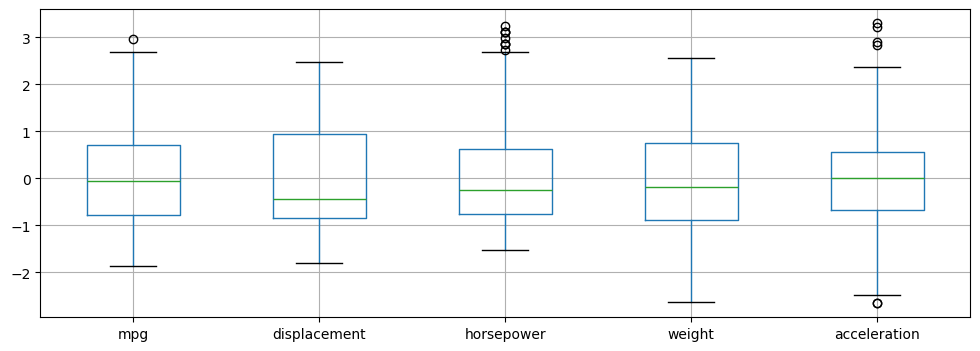

In [22]:
standardized = ((data[numeric_feats] - data[numeric_feats].mean())
/ data[numeric_feats].std())
standardized.boxplot(column=numeric_feats, figsize= (12, 4))

In [23]:
%matplotlib inline

In [24]:
len(numeric_feats)

5

array([[<Axes: title={'center': 'mpg'}>,
        <Axes: title={'center': 'displacement'}>,
        <Axes: title={'center': 'horsepower'}>],
       [<Axes: title={'center': 'weight'}>,
        <Axes: title={'center': 'acceleration'}>, <Axes: >]], dtype=object)

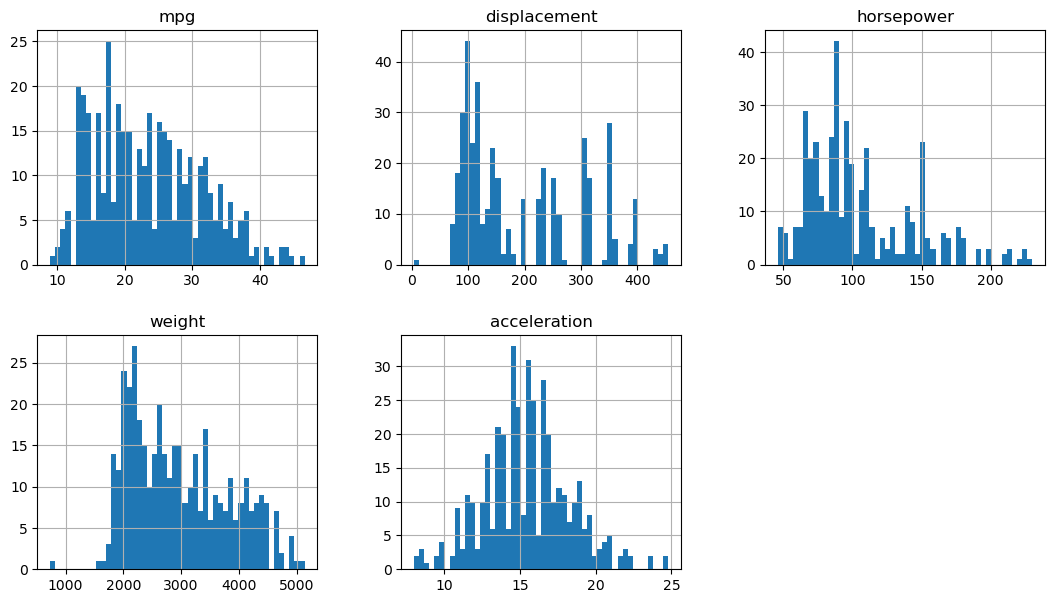

In [25]:
data[numeric_feats].hist(bins=50,layout=(2,3),figsize=(13,7))

<Axes: xlabel='cylinders'>

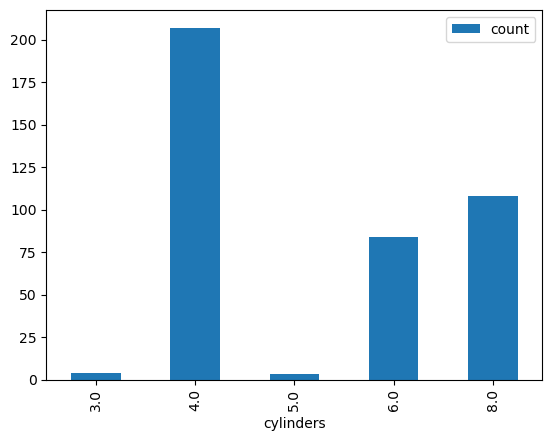

In [26]:
(data.cylinders
.value_counts()
.reset_index()
.sort_values(by="cylinders")
.plot.bar(x="cylinders")
)

Usually cars which odd numbers are 3 or 5 harder harder to deal with in terms of engineering but still you would want to keep them in the analysis. 

### c. Analysis of bivariate and multivariate relationships

Before diving into modeling, it's important to explore how features relate to each other. After checking individual distributions, the next step in EDA is identifying redundant or highly correlated features—such as duplicates, highly collinear variables, or different representations of the same concept. Removing or consolidating such features can simplify your dataset and improve model performance. In this section, we'll use correlation matrices to detect and visualize collinearity among numeric features.


#### Numerical-vs-Numerical

<Axes: >

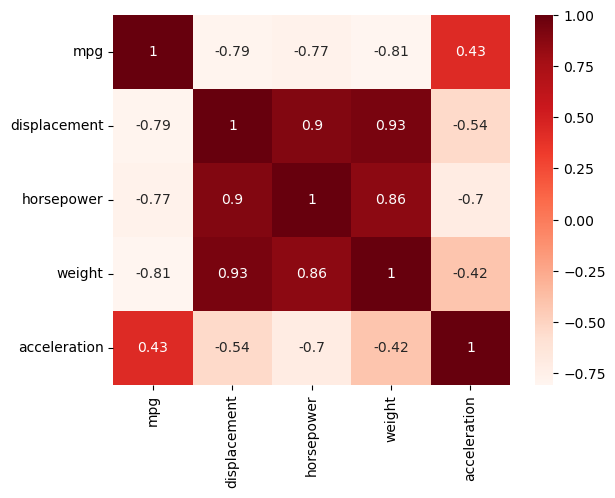

In [28]:
# Make sure you have seaborn version 0.13 else the annotations won't appear
import seaborn as sns
corr = data[numeric_feats].corr()
sns.heatmap(corr, cmap="Reds",annot=True)

#### Categorical-vs-Categorical (contigency table)

When dealing with a small number of features, a full correlation matrix is easy to interpret. But with many features, it's more effective to focus on correlations above a certain threshold (e.g., |0.98|). High positive or negative correlations indicate collinearity, which can harm model performance and interpretability. Reducing collinearity by removing redundant features helps avoid issues during training.

For categorical or mixed feature types, correlation may not apply. In those cases, we use association measures like Cramer’s V, especially after discretizing numeric features. The code below explores how to detect and handle collinearity using both correlation and association techniques.

**Notes**: 
* Calculate the Position of deciles(q=10): Use the formula for ungrouped data: $P_k = \frac{k\times(N + 1)}{q}$
* cramerV is between [0,1]; where 1 means high correlations ($H_o$ is the the values are independent)



In [74]:
# Importing from Scipy the function for computing the chi-square test of independence
from scipy.stats import chi2_contingency #A

# Cramer's V having as input the score chi-square test of independence and the table it has been derived from
def cramerV(chi2, table):
    n = table.values.sum() # counting all the elements in the table
    minimum_dimension = min(table.shape)-1 # figuring out the minimum dimension of the table
    result = ((chi2 / n) / minimum_dimension)**0.5 #result is the root of the chi-square score divided by the number of elements in the table and its minimum dimension
    return result

# transforming the numeric feature mpg into deciles so they can fit into a table
deciles = pd.qcut(data.mpg, q=10, labels=False)

# creating the table between the model_year and mpg deciles to estimate their association
table = pd.crosstab(data.model_year, deciles)

# returning the score, the p-value, the degrees of freedom, and the expected table based on marginal probabilities
chi2, p, dof, expected = chi2_contingency(observed=table) #H

# print the resulting Cramer’s V
print(cramerV(chi2, table)) 

0.28759294860603984


In [75]:
data['deciles'] = deciles

<Axes: xlabel='model_year', ylabel='deciles'>

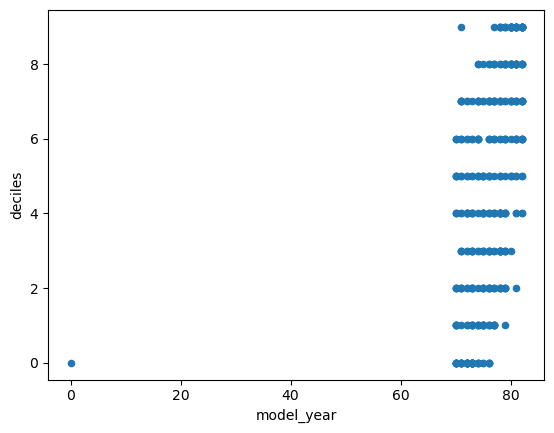

In [85]:
import matplotlib.pyplot as plt
data.plot(x='model_year',y='deciles',kind='scatter')

#### Multivariate Exploration and Dimensionality Reduction

As the final step in EDA, it's important to examine your dataset from a **multivariate perspective** to detect patterns, clusters, or anomalies that may not be visible in univariate or bivariate views. This involves projecting high-dimensional data into **lower dimensions** for visualization.

Common techniques include:

* **PCA** and **SVD** – linear methods useful for summarizing data structure.
* **t-SNE** and **UMAP** – nonlinear methods ideal for uncovering complex patterns and clusters.

While powerful, these methods can produce different results depending on hyperparameters and may be computationally intensive. Still, they are valuable tools when used alongside traditional EDA methods. For large datasets, GPU-based libraries like **NVIDIA RAPIDS** can significantly speed up computations.


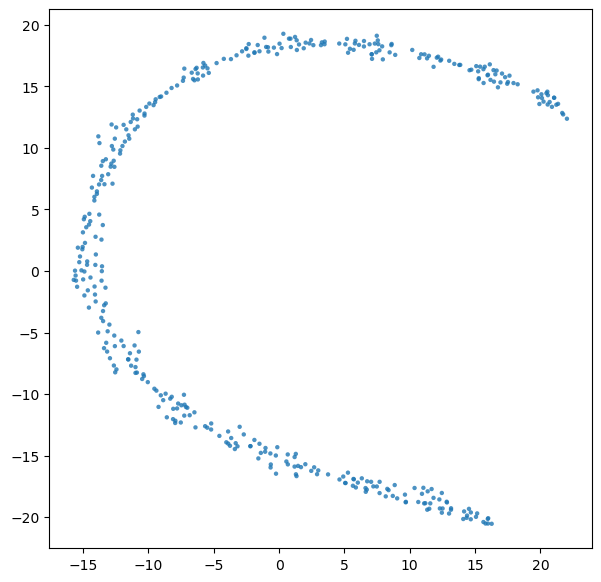

In [87]:
from sklearn.manifold import TSNE 

# create model
tsne = TSNE(n_components=2, 
            perplexity=30., 
            init="random", 
            learning_rate="auto",
            random_state=42)

# use only numeric and ordinal columns & impute
X = data[numeric_feats + ordinal_feats].fillna(data[numeric_feats + ordinal_feats].mean())

# project 
projection_2D = tsne.fit_transform(X) 


plt.figure(figsize=(7, 7))
plt.scatter(projection_2D[:, 0], projection_2D[:, 1],
            edgecolor='none', 
            alpha=0.80, 
            s=10) 
plt.show()

## 6. Summary


Despite differences across domains and organizations, tabular datasets share common traits that allow us to define effective data handling and modeling practices:

- **Rows represent units of observation**, and it’s important to recognize when data is non-IID (not independent and identically distributed). Non-IID data can affect key procedures such as bootstrapping, subsampling, and cross-validation.<br></br>

- **Columns can contain various data types**:
  - Numeric (floats and integers)
  - Ordinal (ordered integers)
  - Categorical (with low or high cardinality)
  - Dates  
   Each type requires tailored processing and analysis techniques. Mastering the `pandas` library—particularly the `DataFrame` structure—is essential for working with these feature types.
<br></br>

- **Data issues vary by column type**, including:
  - Constant or quasi-constant features  
  - Duplicated or highly collinear features  
  - Irrelevant features  
  - Rare categories and inconsistencies  
  - Missing values  
  - Information leakage
    
  Each issue has specific remedies that should be applied accordingly.<br></br>

- **Accessing tabular datasets is easy** thanks to open repositories such as:
  - [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php)  
  - [Kaggle Datasets](https://www.kaggle.com/datasets)  
  - [Google Dataset Search](https://datasetsearch.research.google.com)
    <br></br>

- **Exploratory Data Analysis (EDA)** is crucial for cleaning and understanding data. Tools such as:
  - `value_counts()`  
  - `describe()`  
  - Histograms and box plots  
  - Correlation matrices  
  - Dimensionality reduction techniques (e.g. t-SNE) help reveal patterns, structure, and data quality issues.
